In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent  
project_root
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from importlib import reload

In [3]:
 # reload(ticker_loader)

In [4]:
import main_real_data
from src import logging
from src.filters import abosolution_momentum_filter,trend_acceleration_filter,base_filter
from src import ticker_loader
from src.scorers import moment_scorers,mean_reversion_scorers
from src.selectors import cross_selectors,self_selectors

In [5]:
log_filename=logging.get_log_filename('backtest_real')
print(log_filename)

backtest_real_20260723_214539.log


In [6]:
tickers_2022_nas=ticker_loader.load_total_tickers_nasdaq_2022()
tickers_xlu=ticker_loader.load_xlu_tickers()
tickers_overall=ticker_loader.load_overall_market()

In [7]:
tickers_xlp=ticker_loader.load_xlp_tickers()
tickers_xlre=ticker_loader.load_xlre_tickers()

In [8]:
moment_scorers={
    'risk_adj':moment_scorers.SimpleRiskAdjustedScorer(),
    'linear_strategy':moment_scorers.TraditionalLinearRegressionScorer(),
    'advanced_risk_adjust':moment_scorers.GeometricDriftScorer(),
    'advanced_info_strat':moment_scorers.WeightedLinearRegressionScorer()
}
reverse_scorers={
    'mean_reverse':mean_reversion_scorers.MeanReversionScorer(),
    'bollinger_reversion':mean_reversion_scorers.BollingerReversionScorer(),
}

In [9]:
# trend_filter=trend_acceleration_filter.TrendAccelerationDiagnostic(backtester.universe_data['price'])
filter=base_filter.NullFilter()

In [10]:
select_type=self_selectors.SelfSelector #strategy_selector.SingleHorizonStrategy

## set the backteseter

In [11]:
backtester = main_real_data.RealDataBacktester(tickers=tickers_xlre, start_date="2022-01-01", end_date="2026-04-01", log_file=f"data/{log_filename}")

In [12]:
backtester.fetch_data()

[*********************100%***********************]  20 of 20 completed

price shape before drop: (1064, 20)
price shape after drop: (1064, 20)
volume shape after drop: (1064, 20)


In [13]:
# backtester.set_filter(abosolution_momentum_filter.AbsoluteMomentumFilter)
backtester.set_filter(filter)
backtester.set_strategy_selector(select_type)
backtester.build_strategies(reverse_scorers,)

  **create strategy for mean_reverse
  **create strategy for bollinger_reversion


{'mean_reverse': <src.selectors.self_selectors.SelfSelector at 0x110f5f0e0>,
 'bollinger_reversion': <src.selectors.self_selectors.SelfSelector at 0x110f5f350>}

In [14]:
for name in backtester.strategies:
    print(f'{name} .... {backtester.strategies[name].scorer}')

mean_reverse .... <src.scorers.mean_reversion_scorers.MeanReversionScorer object at 0x110f7e450>
bollinger_reversion .... <src.scorers.mean_reversion_scorers.BollingerReversionScorer object at 0x110f7e480>


In [15]:
backtester.strategies

{'mean_reverse': <src.selectors.self_selectors.SelfSelector at 0x110f5f0e0>,
 'bollinger_reversion': <src.selectors.self_selectors.SelfSelector at 0x110f5f350>}

In [16]:
states = backtester.run_backtest()

[2026-07-23 21:45:51] INFO [backtest_logger]: ******* mean_reverse *******
[2026-07-23 21:45:51] INFO [backtest_logger]: Initializing Backtest Engine...
[2026-07-23 21:45:51] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2022-01-31 ===
[2026-07-23 21:45:51] INFO [backtest_logger]:     2022-02-01 00:00:00:CORE_BUY DLR ... 789.85@126.35, fee: 99.9
[2026-07-23 21:45:51] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2022-02-28 ===
[2026-07-23 21:45:51] INFO [backtest_logger]:     2022-03-01 00:00:00:CORE_SELL DLR ... 789.85@114.7, fee: 90.6
[2026-07-23 21:45:51] INFO [backtest_logger]:     2022-03-01 00:00:00:CORE_BUY INVH ... 1405.34@32.17, fee: 45.26
[2026-07-23 21:45:51] INFO [backtest_logger]:     2022-03-01 00:00:00:CORE_BUY AMT ... 229.08@197.37, fee: 45.26
[2026-07-23 21:45:51] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2022-03-31 ===
[2026-07-23 21:45:51] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2022-04-29 ===
[2026-07-23 21:45:51] INFO [

In [17]:
backtester.states

{'mean_reverse': <src.global_state.GlobalState at 0x110ffbe90>,
 'bollinger_reversion': <src.global_state.GlobalState at 0x11159edb0>}

# analysis

In [84]:
import pandas as pd
from src import metrics,analysis

In [85]:
backtester.fetch_bench_data(['XLU','QQQ','SPY','XLP','XLRE'])

[*********************100%***********************]  5 of 5 completed


In [86]:
states

{'mean_reverse': <src.global_state.GlobalState at 0x1124c8530>,
 'bollinger_reversion': <src.global_state.GlobalState at 0x1124af3b0>}

In [87]:
effective_date='2023-01-31'
bench_price=backtester.bench_universe_data['price']
df_prices=backtester.universe_data['price']
today=df_prices.index[-1]
market_prices=df_prices.loc[today]

In [88]:
df_nav_list=[]
for strat_name in states:
    print(strat_name)
    g_state=states[strat_name]
    df_nav=g_state.export_nav_dataframe()[['Total_NAV']]
    df_nav=df_nav.rename({'Total_NAV':strat_name},axis=1)
    df_nav_list.append(df_nav)

mean_reverse
bollinger_reversion


In [89]:
df1=pd.concat([bench_price]+df_nav_list,axis=1)
df2=df1.loc[effective_date:]
metrics.calculate_metrics(df2)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
XLU,0.128822,0.991311,1.620158,0.183923,0.700414
QQQ,0.244466,1.455030,2.455617,0.227683,1.073712
SPY,0.175828,1.377511,2.295792,0.187552,0.937488
XLP,0.062725,0.689159,1.177150,0.133655,0.469310
XLRE,0.037434,0.360120,0.587445,0.211289,0.177169
mean_reverse,-0.036575,-0.032631,-0.054339,0.320463,-0.114131
bollinger_reversion,-0.028879,-0.346318,-0.468103,0.167516,-0.172397


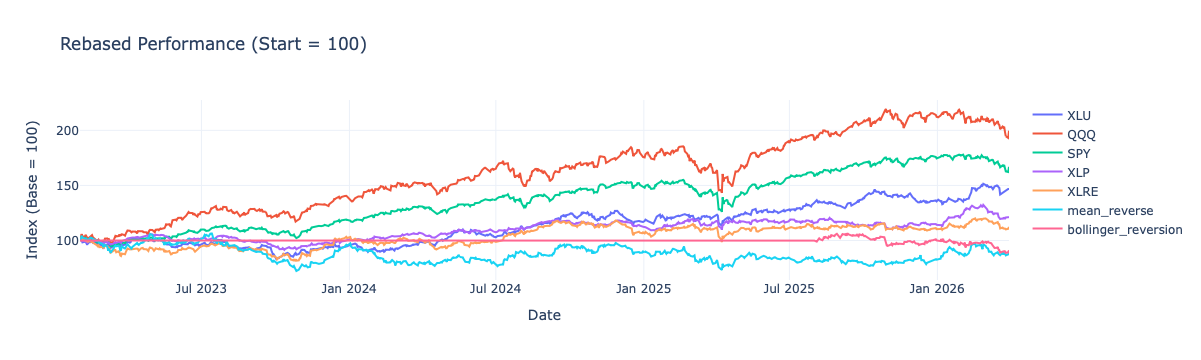

In [90]:
analysis.plot_rebased_performance(df2)#['2025-04-01':])

# different in time spot

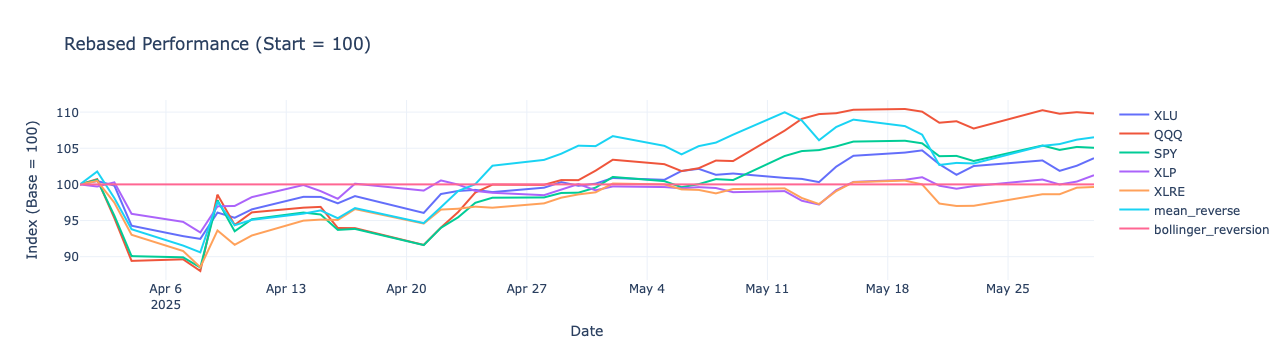

In [91]:
analysis.plot_rebased_performance(df2,'2025-04-01', '2025-06-01')

# state display

In [92]:
states.keys()

dict_keys(['mean_reverse', 'bollinger_reversion'])

In [93]:
g_state=states['bollinger_reversion']

In [94]:
g_state.display_current_state(today,market_prices)

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.1% Cash
  - Core Liquid Cash : $100.00
  - Total Core NAV   : $91,149.72
          Shares    Price Market Value Sleeve Weight
Ticker                                              
AVB     562.5887  $161.84   $91,049.72        99.89%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $91,149.72
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------



# daily level check

In [18]:
from src import audit,analysis

In [19]:
import numpy as np
import pandas as pd

In [20]:
backtester.ledger_dict.keys()

dict_keys(['mean_reverse', 'bollinger_reversion'])

## generate data from ledger

In [21]:
check_key='mean_reverse'

In [22]:
audit_ledger=backtester.ledger_dict[check_key]
g_state=backtester.states[check_key]

In [23]:
metric_keys=audit_ledger[0].telemetry.metrics.keys()
df_ledger=audit.analyze_audit_trail(audit_ledger,metric_keys)
df_ledger.shape

(1173, 11)

what is ledger: date, ticker (all ticker), main metrics in the score calculation

In [38]:
df_price=backtester.universe_data['price']

In [41]:
df_price.loc[df_price.index<='2022-01-31','AMT']

Date
2022-01-03    247.312469
2022-01-04    244.194855
2022-01-05    228.477768
2022-01-06    228.754105
2022-01-07    230.213501
2022-01-10    228.339569
2022-01-11    224.954300
2022-01-12    224.004379
2022-01-13    220.593231
2022-01-14    216.430771
2022-01-18    216.093933
2022-01-19    215.031738
2022-01-20    212.389221
2022-01-21    211.370132
2022-01-24    214.513641
2022-01-25    216.353058
2022-01-26    209.504852
2022-01-27    204.176544
2022-01-28    213.105972
2022-01-31    217.190704
Name: AMT, dtype: float64

In [44]:
reload(audit)

<module 'src.audit' from '/Users/zhigangyu/Documents/codes/stock_simulation_system/src/audit.py'>

In [46]:
dir(backtester)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'broker',
 'build_strategies',
 'end_date',
 'fetch_bench_data',
 'fetch_data',
 'ledger_dict',
 'logger',
 'portfolio_filter',
 'run_backtest',
 'save_states',
 'selector_type',
 'set_filter',
 'set_strategy_selector',
 'start_date',
 'states',
 'strategies',
 'tickers',
 'universe_data']

In [48]:
reverse_scorers

{'mean_reverse': <src.scorers.mean_reversion_scorers.MeanReversionScorer at 0x110f7e450>,
 'bollinger_reversion': <src.scorers.mean_reversion_scorers.BollingerReversionScorer at 0x110f7e480>}

In [47]:
audit.verify_score(df_ledger, df_price, ticker="AMT", date="2022-01-31", scorer=reverse_scorers, window=60)

AttributeError: 'dict' object has no attribute 'compute_score'

In [42]:
df_ledger.loc[df_ledger['date']=='2022-01-31']

,date,ticker,z_score,raw_z_score,window_mean,window_std,last_price,n_bars_used,raw_score,selector_summary,final_weight
0,2022-01-31,AMT,-0.358895,-0.358895,221.150237,11.032567,217.190704,20.0,0.358895,NaN,0.0
1,2022-01-31,AVB,-0.510060,-0.510060,210.442254,4.173940,208.313293,20.0,0.510060,NaN,0.0
2,2022-01-31,CBRE,-0.282315,-0.282315,102.537001,4.239965,101.339996,20.0,0.282315,NaN,0.0
3,2022-01-31,CCI,-0.504998,-0.504998,148.916715,6.566198,145.600800,20.0,0.504998,NaN,0.0
4,2022-01-31,DLR,-1.091438,-1.091438,134.207219,6.028546,127.627434,20.0,1.091438,NaN,1.0
5,2022-01-31,EQIX,-0.614142,-0.614142,683.142252,34.910267,661.702393,20.0,0.614142,NaN,0.0
6,2022-01-31,EQR,-0.546430,-0.546430,74.642366,1.263672,73.951859,20.0,0.546430,NaN,0.0
7,2022-01-31,ESS,-0.847727,-0.847727,287.784689,8.064049,280.948578,20.0,0.847727,NaN,0.0
8,2022-01-31,EXR,-0.616116,-0.616116,169.353817,8.063888,164.385529,20.0,0.616116,NaN,0.0
9,2022-01-31,INVH,-0.535886,-0.535886,36.486934,1.138658,35.876743,20.0,0.535886,NaN,0.0


In [24]:
# history score and related info of each rebalance day
df_ledger.head()

,date,ticker,z_score,raw_z_score,window_mean,window_std,last_price,n_bars_used,raw_score,selector_summary,final_weight
0,2022-01-31,AMT,-0.358895,-0.358895,221.150237,11.032567,217.190704,20.0,0.358895,NaN,0.0
1,2022-01-31,AVB,-0.510060,-0.510060,210.442254,4.173940,208.313293,20.0,0.510060,NaN,0.0
2,2022-01-31,CBRE,-0.282315,-0.282315,102.537001,4.239965,101.339996,20.0,0.282315,NaN,0.0
3,2022-01-31,CCI,-0.504998,-0.504998,148.916715,6.566198,145.600800,20.0,0.504998,NaN,0.0
4,2022-01-31,DLR,-1.091438,-1.091438,134.207219,6.028546,127.627434,20.0,1.091438,NaN,1.0


In [102]:
df_enhanced_ledger_effect.loc[[df_enhanced_ledger_effect['cum_pnl'].idxmin()]]

,date,ticker,shares_holding,current_price,current_value,yesterday_value,return_change,pnl_dollar,entry_price,cum_pnl,weight,shares_change,is_rebalance_day,ym
21221,2026-03-27,AVB,562.59,157.568756,88646.606496,90079.856371,-0.015911,-1433.249875,177.39444,-11153.731333,1.0,0.0,False,202603


In [103]:
## get df_nav of the portoflio from state

In [104]:
df_sate_nav=g_state.export_nav_dataframe()[['Total_NAV']]
df_sate_nav=df_sate_nav.rename({'Total_NAV':'nav'},axis=1)
df_sate_nav['diff']=df_sate_nav.nav.diff()

In [105]:
# largest portfolio drop
df_sate_nav.loc[[df_sate_nav['diff'].idxmin()]]

,nav,diff
Date,,
2023-07-17,67411.65785,-5247.11015


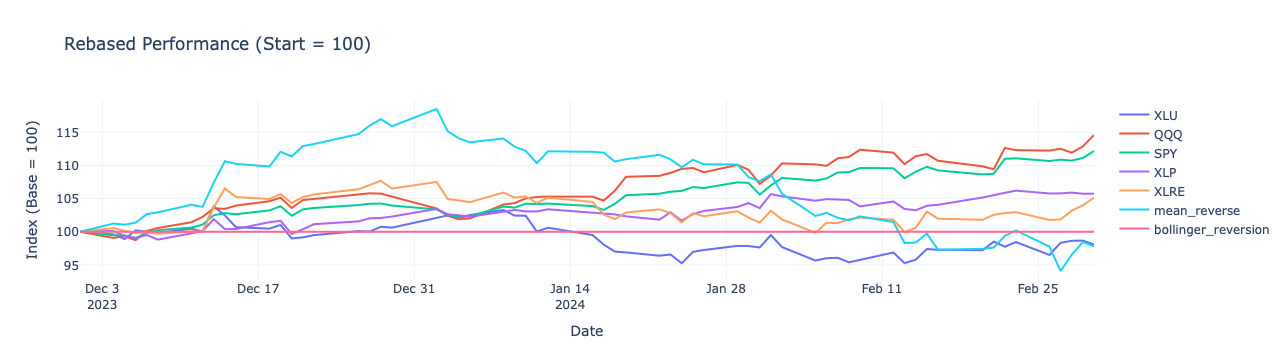

In [106]:
analysis.plot_rebased_performance(df2,'2023-12-01','2024-03-01')

## from transcation info from log file

- df_trade is the transaction record
- df_trade3 is the balance sheet (the stock holdings on head after rebalance)

In [107]:
df_trades=logging.parse_backtest_log_by_strategy(f'data/{log_filename}')

Parsing strategy: mean_reverse
Parsing strategy: bollinger_reversion


In [108]:
df_trades.keys()

dict_keys(['mean_reverse', 'bollinger_reversion'])

In [109]:
df_trade=df_trades[check_key]

In [110]:
df_trade['shares2']=np.where(df_trade['type']=='CORE_SELL',-1*df_trade['shares'],df_trade['shares'])

df_ledger['trade_date']=df_ledger['date']+ pd.Timedelta(days=1)
df_trade2=df_trade.merge(df_ledger[['trade_date','ticker','final_weight']],left_on=['date','ticker'],right_on=['trade_date','ticker'])

df_trade3=analysis.generate_balance_df(df_trade,daily_resolution=False)
df_trade3=analysis.unpivot_balance_df(df_trade3)

In [114]:
df_trade3.groupby('ticker').count()

,date,shares
ticker,,
AMT,2,2
AVB,3,3
CBRE,1,1
CCI,4,4
DLR,15,15
EQIX,2,2
EQR,2,2
ESS,2,2
EXR,1,1


In [49]:
# df_trade3=df_trade3.loc[abs(df_trade3['shares'])>.1]a

In [115]:
df_prices=backtester.universe_data['price']
df_prices.index.name='date'
df_enhanced_ledger=analysis.build_enhanced_ledger_from_balances(df_trade3,df_prices)

# holding stock and the p&l
df_enhanced_ledger_effect=df_enhanced_ledger.loc[df_enhanced_ledger.shares_holding!=0]
df_enhanced_ledger_effect['ym']=df_enhanced_ledger_effect['date'].dt.year*100+df_enhanced_ledger_effect['date'].dt.month
df_enhanced_ledger_effect.tail()

,date,ticker,shares_holding,current_price,current_value,yesterday_value,return_change,pnl_dollar,entry_price,cum_pnl,weight,shares_change,is_rebalance_day,ym
21224,2026-03-27,DLR,5.684342e-14,174.258148,9.905429e-12,9.867596e-12,0.003834,3.783258e-14,154.507384,1.122701e-12,1.678886e-16,0.0,False,202603
21242,2026-03-30,CBRE,4.477500e+02,133.139999,5.961343e+04,5.900002e+04,0.010397,6.134153e+02,144.970001,-5.296883e+03,1.000000e+00,0.0,False,202603
21244,2026-03-30,DLR,5.684342e-14,174.019745,9.891877e-12,9.905429e-12,-0.001368,-1.355166e-14,154.507384,1.109149e-12,1.659337e-16,0.0,False,202603
21262,2026-03-31,CBRE,4.477500e+02,135.460007,6.065222e+04,5.961343e+04,0.017425,1.038783e+03,144.970001,-4.258100e+03,1.000000e+00,0.0,False,202603
21264,2026-03-31,DLR,5.684342e-14,179.016434,1.017591e-11,9.891877e-12,0.028713,2.840289e-13,154.507384,1.393178e-12,1.677747e-16,0.0,False,202603


In [116]:
df_enhanced_ledger.loc[(df_enhanced_ledger['date']=='2026-03-31') & (df_enhanced_ledger['shares_holding']>0)]

,date,ticker,shares_holding,current_price,current_value,yesterday_value,return_change,pnl_dollar,entry_price,cum_pnl,weight,shares_change,is_rebalance_day
21262,2026-03-31,CBRE,4.477500e+02,135.460007,6.065222e+04,5.961343e+04,0.017425,1.038783e+03,144.970001,-4.258100e+03,1.000000e+00,0.0,False
21264,2026-03-31,DLR,5.684342e-14,179.016434,1.017591e-11,9.891877e-12,0.028713,2.840289e-13,154.507384,1.393178e-12,1.677747e-16,0.0,False


In [117]:
# chech the nav by g_state record and our log history, mainly match
df1=df_enhanced_ledger.loc[df_enhanced_ledger['is_rebalance_day']]
df2=df1.groupby('date')[['current_value']].sum()
df_state_nav_match=df_sate_nav.merge(df2, right_index=True,left_index=True)
df_state_nav_match.tail() # almost match 

,nav,diff,current_value
Date,,,
2025-11-03,54114.259411,463.255190,54059.511435
2025-12-01,55742.139384,-606.335521,55686.378655
2026-01-02,56490.907764,83.966738,56435.024054
2026-02-02,59291.806085,-1075.086820,59233.210360
2026-03-02,64975.809420,-862.501547,64910.318047


In [121]:
# last loss on holding
check_date=df1.loc[df1['cum_pnl'].idxmin(),'date']
df1.loc[df1['cum_pnl'].idxmin()]

date                2023-01-03 00:00:00
ticker                             INVH
shares_holding                  2401.16
current_price                  25.61273
current_value               61500.26283
yesterday_value            62232.026604
return_change                  -0.01282
pnl_dollar                  -797.844618
entry_price                    27.50635
cum_pnl                    -4546.883973
weight                              1.0
shares_change                      2.58
is_rebalance_day                   True
Name: 5029, dtype: object

In [56]:
# first_date

In [122]:
# check_tickers=df_trade3.loc[(df_trade3['date']>='2022-04-01')&(df_trade3['date']<'2022-06-01'),'ticker'].tolist()
check_tickers=['DLR']

In [123]:
# delta_days=70

# first_date=check_date+pd.Timedelta(days=-delta_days)
# last_date=check_date+pd.Timedelta(days=+delta_days)

In [124]:
df_plot=df_enhanced_ledger#.loc[(df_enhanced_ledger['date']>=first_date)&(df_enhanced_ledger['date']<=last_date)]

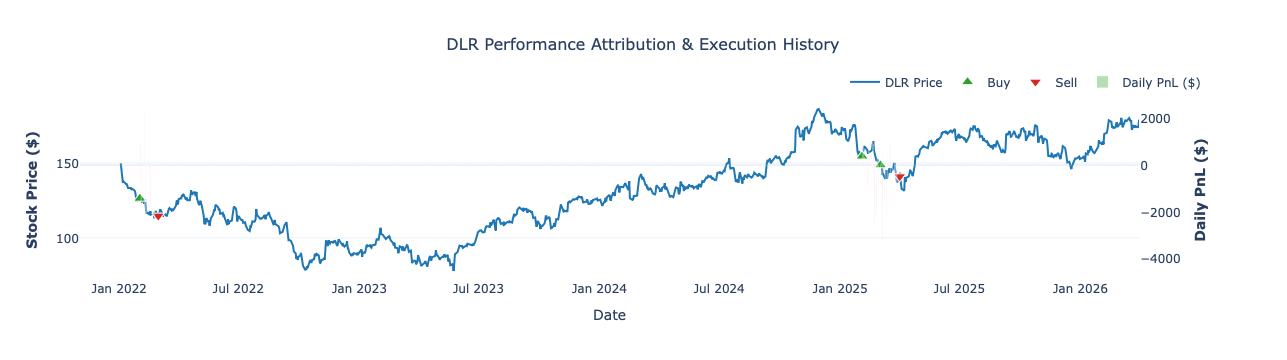

In [125]:
figs=analysis.plot_all_tickers(df_plot,check_tickers)

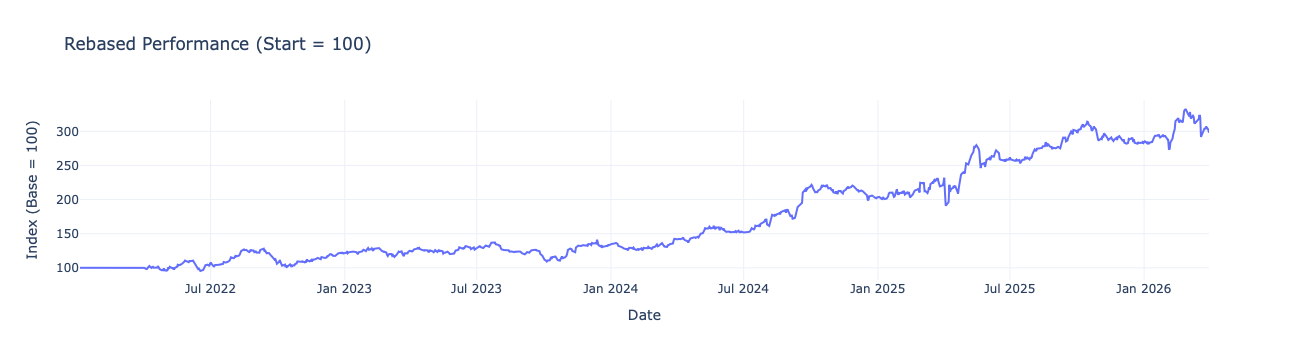

In [153]:
fig=analysis.plot_rebased_performance(df_nav)
fig

In [154]:
df_enhanced_ledger_effect.head()

,date,ticker,shares_holding,current_price,current_value,yesterday_value,return_change,pnl_dollar,entry_price,cum_pnl,weight,shares_change,is_rebalance_day
1864,2022-04-01,AWK,216.40,153.727982,33266.735211,0.000000,0.00000,0.000000,153.727982,0.000000,0.333333,216.40,True
1881,2022-04-01,NRG,968.06,34.364433,33266.833289,0.000000,0.00000,0.000000,34.364433,0.000000,0.333334,968.06,True
1882,2022-04-01,PCG,2758.53,12.059593,33266.749632,0.000000,0.00000,0.000000,12.059593,0.000000,0.333333,2758.53,True
1894,2022-04-04,AWK,216.40,151.369827,32756.430621,33266.735211,-0.01534,-510.304590,153.727982,-510.304590,0.333856,0.00,False
1911,2022-04-04,NRG,968.06,33.711159,32634.424342,33266.833289,-0.01901,-632.408947,34.364433,-632.408947,0.332613,0.00,False


In [210]:
df_enhanced_ledger_effect.head()

,date,ticker,shares_holding,current_price,current_value,yesterday_value,return_change,pnl_dollar,entry_price,cum_pnl,weight,shares_change,is_rebalance_day,ym
1864,2022-04-01,AWK,216.40,153.727982,33266.735211,0.000000,0.00000,0.000000,153.727982,0.000000,0.333333,216.40,True,202204
1881,2022-04-01,NRG,968.06,34.364433,33266.833289,0.000000,0.00000,0.000000,34.364433,0.000000,0.333334,968.06,True,202204
1882,2022-04-01,PCG,2758.53,12.059593,33266.749632,0.000000,0.00000,0.000000,12.059593,0.000000,0.333333,2758.53,True,202204
1894,2022-04-04,AWK,216.40,151.369827,32756.430621,33266.735211,-0.01534,-510.304590,153.727982,-510.304590,0.333856,0.00,False,202204
1911,2022-04-04,NRG,968.06,33.711159,32634.424342,33266.833289,-0.01901,-632.408947,34.364433,-632.408947,0.332613,0.00,False,202204


In [211]:
df4=df_enhanced_ledger_effect.loc[df_enhanced_ledger_effect['is_rebalance_day']]

In [214]:
df4.to_csv('data/check.csv')

In [230]:
df_ym_ticker=df_enhanced_ledger_effect.groupby(['ym','ticker'])[['cum_pnl']].last().reset_index()
df_ym=df_ym_ticker.groupby('ym')[['cum_pnl']].sum()

In [235]:
df_ym.cum_pnl.max()

np.float64(44325.49006164551)

In [238]:
df_ym.sum()

cum_pnl    165874.097973
dtype: float64

In [239]:
df_ym

,cum_pnl
ym,
202204,-3747.920889
202205,12027.591413
202206,-590.995995
202207,4897.754721
202208,11281.873366
202209,-18094.555915
202210,-10625.689101
202211,6959.670072
202212,6961.287148
